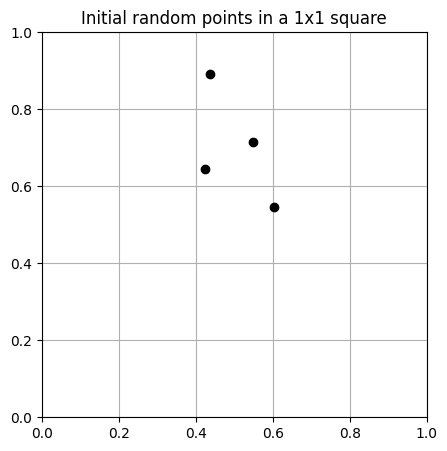

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import Voronoi, voronoi_plot_2d

# Set a seed for reproducibility
np.random.seed(0)

# 1. Start with a 1x1 square (2D) continuous space.
# We'll define this by the boundaries [0, 1] x [0, 1].

# 2. Place 2-5 points in it.
num_points = 4
points = np.random.rand(num_points, 2)

# 3. Plot/visualize the points.
fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(points[:, 0], points[:, 1], 'ko')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_title("Initial random points in a 1x1 square")
ax.set_aspect('equal', adjustable='box')
plt.grid(True)
plt.show()


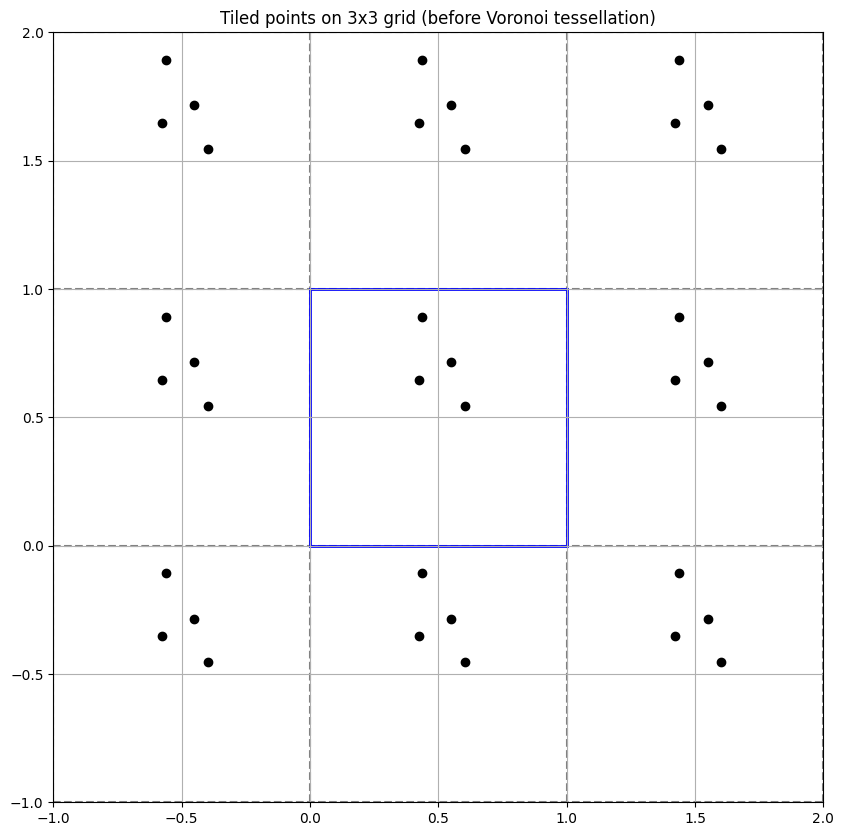

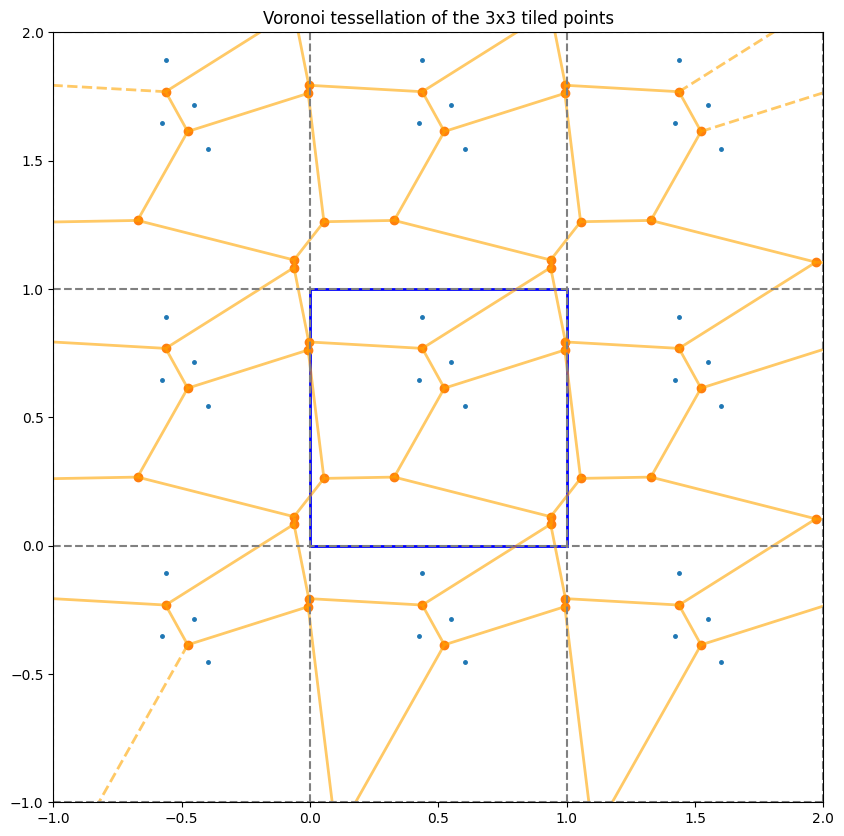

In [2]:
# 4. Make a 3x3 array square of duplicate squares.
tiled_points = []
for i in range(-1, 2):
    for j in range(-1, 2):
        tiled_points.append(points + np.array([i, j]))
tiled_points = np.concatenate(tiled_points)

# Plot the tiled points on the 3x3 grid before the Voronoi tessellation.
fig, ax = plt.subplots(figsize=(10, 10))
ax.plot(tiled_points[:, 0], tiled_points[:, 1], 'ko')
# Draw the grid lines for reference
for i in range(-1, 3):
    ax.axvline(i, color='gray', linestyle='--', zorder=0)
    ax.axhline(i, color='gray', linestyle='--', zorder=0)
# Highlight the middle square
rect = plt.Rectangle((0, 0), 1, 1, fill=False, edgecolor='blue', linewidth=2, linestyle='-')
ax.add_patch(rect)
ax.set_xlim(-1, 2)
ax.set_ylim(-1, 2)
ax.set_aspect('equal', adjustable='box')
ax.set_title("Tiled points on 3x3 grid (before Voronoi tessellation)")
plt.grid(True)
plt.show()


# 5. Voronoi tessellate the entire 3x3 grid.
vor = Voronoi(tiled_points)

# Visualize the tessellation on the 3x3 grid
fig, ax = plt.subplots(figsize=(10, 10))
voronoi_plot_2d(vor, ax=ax, show_vertices=True, line_colors='orange',
                line_width=2, line_alpha=0.6, point_size=5)

# Draw the grid lines
for i in range(-1, 3):
    ax.axvline(i, color='gray', linestyle='--')
    ax.axhline(i, color='gray', linestyle='--')

# Highlight the middle square
rect = plt.Rectangle((0, 0), 1, 1, fill=False, edgecolor='blue', linewidth=2, linestyle='-')
ax.add_patch(rect)

ax.set_xlim(-1, 2)
ax.set_ylim(-1, 2)
ax.set_title("Voronoi tessellation of the 3x3 tiled points")
ax.set_aspect('equal', adjustable='box')
plt.show()


--- First Iteration ---
New point to add: [0.93758721 0.11276168]


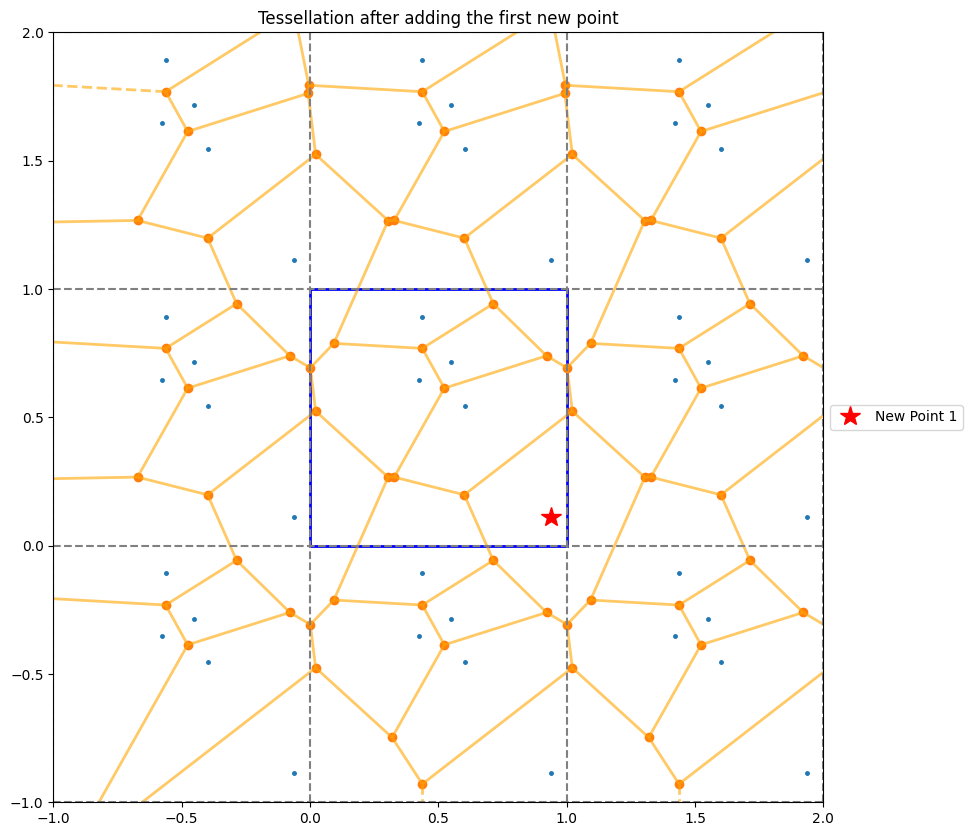


--- Second Iteration ---
New point to add: [0.00124968 0.69257989]


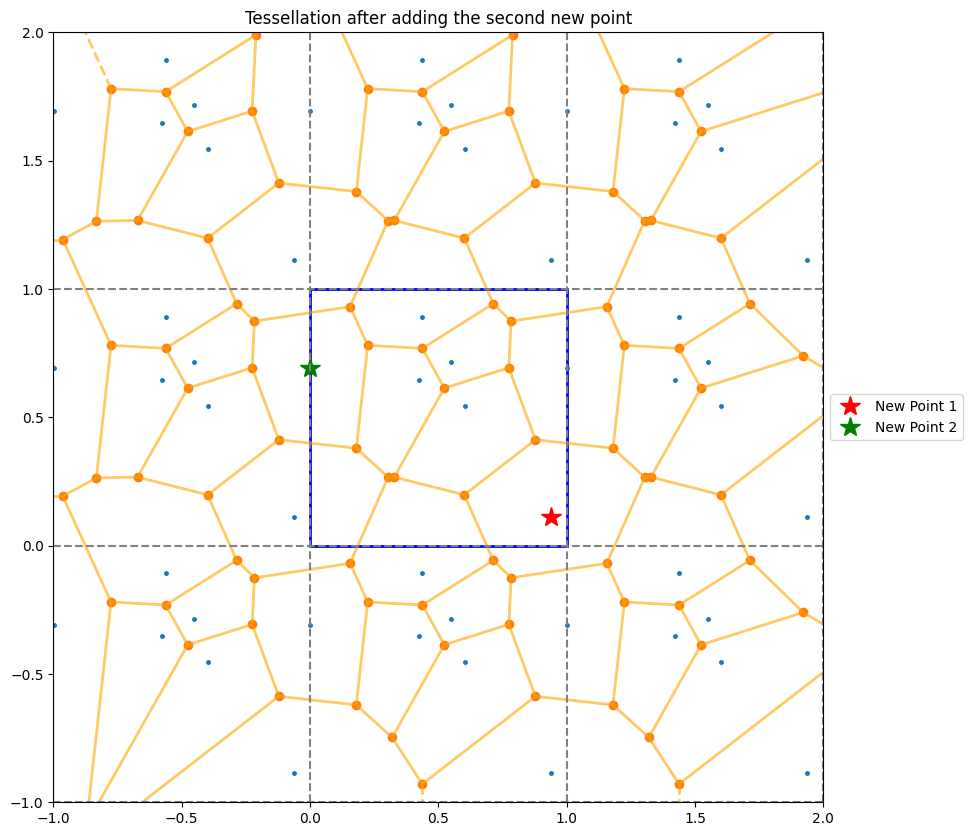

In [7]:
def find_furthest_vertex(vor, bounds=[0, 1, 0, 1]):
    """
    Finds the Voronoi vertex within the given bounds that is furthest from any of the generator points.
    
    Args:
        vor (scipy.spatial.Voronoi): The Voronoi diagram.
        bounds (list): A list [xmin, xmax, ymin, ymax] defining the search area.
        
    Returns:
        numpy.ndarray: The coordinates of the furthest vertex.
    """
    xmin, xmax, ymin, ymax = bounds
    
    # Filter vertices to be within the middle square
    center_vertices = []
    for vertex in vor.vertices:
        if xmin <= vertex[0] <= xmax and ymin <= vertex[1] <= ymax:
            center_vertices.append(vertex)
    center_vertices = np.array(center_vertices)
    
    if len(center_vertices) == 0:
        return None

    # For each vertex, find the distance to the closest generator point
    min_distances = []
    for v in center_vertices:
        # Broadcasting to calculate distances from v to all points in vor.points
        distances = np.sqrt(np.sum((vor.points - v)**2, axis=1))
        min_distances.append(np.min(distances))
    
    # Find the vertex with the maximum minimum distance
    furthest_vertex_index = np.argmax(min_distances)
    new_point = center_vertices[furthest_vertex_index]
    
    return new_point

# --- First Iteration ---
print("--- First Iteration ---")
# 6. In the middle square, place a new point at the tessellation junction
#    which is furthest from all nearby points.
new_point = find_furthest_vertex(vor)
if new_point is not None:
    print(f"New point to add: {new_point}")

    # Add the new point to our original set
    points = np.vstack([points, new_point])

    # 7. Copy that point into the other 8 squares.
    tiled_points = []
    for i in range(-1, 2):
        for j in range(-1, 2):
            tiled_points.append(points + np.array([i, j]))
    tiled_points = np.concatenate(tiled_points)

    # 8. Re-tesselate the whole 3x3.
    vor = Voronoi(tiled_points)

    # Visualize the new tessellation
    fig, ax = plt.subplots(figsize=(10, 10))
    voronoi_plot_2d(vor, ax=ax, show_vertices=True, line_colors='orange',
                    line_width=2, line_alpha=0.6, point_size=5)
    
    # Plot the newly added point in the center square with a different marker
    ax.plot(new_point[0], new_point[1], 'r*', markersize=15, label='New Point 1')

    # Draw the grid lines
    for i in range(-1, 3):
        ax.axvline(i, color='gray', linestyle='--')
        ax.axhline(i, color='gray', linestyle='--')
    rect = plt.Rectangle((0, 0), 1, 1, fill=False, edgecolor='blue', linewidth=2, linestyle='-')
    ax.add_patch(rect)
    
    ax.set_xlim(-1, 2)
    ax.set_ylim(-1, 2)
    ax.set_title("Tessellation after adding the first new point")
    ax.set_aspect('equal', adjustable='box')
    ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.show()

else:
    print("No Voronoi vertices found in the center square.")

# --- Second Iteration ---
print("\n--- Second Iteration ---")
# 9. In the middle square, place another new point at the tessellation junction
#    which is furthest from all nearby points.
new_point_2 = find_furthest_vertex(vor)
if new_point_2 is not None:
    print(f"New point to add: {new_point_2}")

    # Add the new point
    points = np.vstack([points, new_point_2])
    
    # Re-tile
    tiled_points = []
    for i in range(-1, 2):
        for j in range(-1, 2):
            tiled_points.append(points + np.array([i, j]))
    tiled_points = np.concatenate(tiled_points)

    # Re-tessellate
    vor = Voronoi(tiled_points)

    # Visualize
    fig, ax = plt.subplots(figsize=(10, 10))
    voronoi_plot_2d(vor, ax=ax, show_vertices=True, line_colors='orange',
                    line_width=2, line_alpha=0.6, point_size=5)
    ax.plot(new_point[0], new_point[1], 'r*', markersize=15, label='New Point 1')
    ax.plot(new_point_2[0], new_point_2[1], 'g*', markersize=15, label='New Point 2')
    
    for i in range(-1, 3):
        ax.axvline(i, color='gray', linestyle='--')
        ax.axhline(i, color='gray', linestyle='--')
    rect = plt.Rectangle((0, 0), 1, 1, fill=False, edgecolor='blue', linewidth=2, linestyle='-')
    ax.add_patch(rect)
    
    ax.set_xlim(-1, 2)
    ax.set_ylim(-1, 2)
    ax.set_title("Tessellation after adding the second new point")
    ax.set_aspect('equal', adjustable='box')
    ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.show()

else:
    print("No Voronoi vertices found in the center square for the second iteration.")

